MNIST Handwritten Digit Clasification using Deep Learning (Neural Network)

# Importing Dependencies

In [48]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# Import TensorFlow and set configurations before importing other TF components
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(3)

# Import Keras components after TensorFlow setup
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix

# Loading the MNIST data from keras.datasets

In [50]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [51]:
type(X_train)

numpy.ndarray

In [52]:
# Shape of numpy array

print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training data = 60,000 Images

Test data = 10,000 Images

Image dimension --> 28 x 28

Grayscale Image --> 1 channel

In [53]:
# printing the 10th image

print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [54]:
print(X_train[10].shape)

(28, 28)


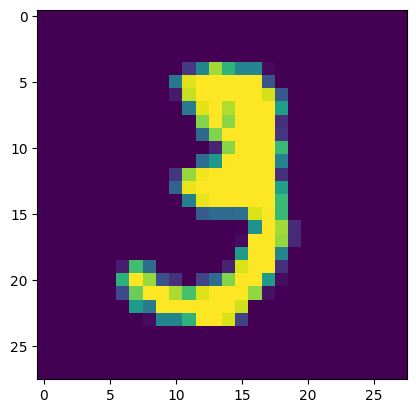

In [55]:
# Display the Image
plt.imshow(X_train[10])
plt.show()

In [56]:
# Print the corresponding label

print(Y_train[10])

3


# Image Labels

In [57]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [58]:
# unique values in Y_train

print(np.unique(Y_train))

[0 1 2 3 4 5 6 7 8 9]


In [59]:
# Unique values in Y_test

print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]


We can use these labels as such or we can also apply One Hot Encoding


All the images have the same dimensions in this dataset, If not, we have to resize all the images to a common dimension

In [60]:
# Scaling the values

X_train = X_train/255   # All the values are in between 0 - 255
X_test = X_test/255

In [61]:
# Printing the 10th Image

print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

# Building The Neural Network

In [62]:
# Setting up the layers of neural network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

d:\# My Learning\Coding\Machine-Learning-Tutorial\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [63]:
# Compiling Neural Network

model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [64]:
# Check if CUDA (GPU) is available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    device = 'cuda'
else:
    print("Using CPU - consider installing CUDA for faster inference")
    device = 'cpu'

CUDA available: True
GPU device: NVIDIA GeForce GTX 1650


In [65]:
# Training the Neural Network

model.fit(X_train, Y_train, epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9136 - loss: 0.2997
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9570 - loss: 0.1439
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9681 - loss: 0.1045
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9748 - loss: 0.0822
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9791 - loss: 0.0672
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9826 - loss: 0.0568
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9854 - loss: 0.0481
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9871 - loss: 0.0408
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9877 - loss: 0.0382
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9895 - loss: 0.0319


Training Data Accuracy = 98.9%

# Accuracy on Test Data

In [66]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(accuracy)
print(loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9708 - loss: 0.1144
0.97079998254776
0.11437802761793137


Test Accuracy = 97.1%

In [67]:
print(X_test.shape)

(10000, 28, 28)


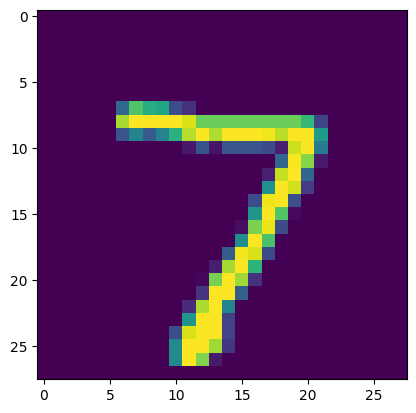

In [68]:
# First data point in X_test

plt.imshow(X_test[0])
plt.show()

In [69]:
# Label 

print(Y_test[0])

7


In [70]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [71]:
print(Y_pred.shape)

(10000, 10)


In [72]:
print(Y_pred[0])

[1.1109088e-02 6.0586259e-04 9.9782747e-01 9.9962616e-01 3.0247529e-10
 9.9111293e-03 1.8187117e-13 9.9999994e-01 2.7069224e-02 9.6730912e-01]


model.predict() gives the prediction probability of each class for that data point

In [73]:
# Converting the prediction probabilities to class label

label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [74]:
# Converting the prediction probabilites to class label for all test data point

Y_pred_labels = []

for i in Y_pred:
    Y_pred_labels.append(np.argmax(i))
print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(2), np.int64(9), np.int64(3), np.int64(3), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test = True Labels

Y_pred_labels = Predicted Labels

# Confusion Matrix

In [75]:
confu_matrix = confusion_matrix(Y_test, Y_pred_labels)

In [76]:
print(confu_matrix)

[[ 963    0    2    2    1    2    4    2    2    2]
 [   0 1114    5    3    0    1    3    5    4    0]
 [   3    0 1010    2    4    0    2    4    6    1]
 [   0    0    9  984    0    3    2    3    7    2]
 [   0    0    5    0  955    0    2    4    2   14]
 [   1    0    0   28    2  847    6    1    6    1]
 [   1    1    1    1    3    7  942    0    2    0]
 [   1    0   15    9    0    0    1  991    3    8]
 [   2    0    6   12    2    4    1    2  942    3]
 [   1    3    0    7   12    7    0    4    8  967]]


Text(0.5, 47.7222222222222, 'Predicted Labels')

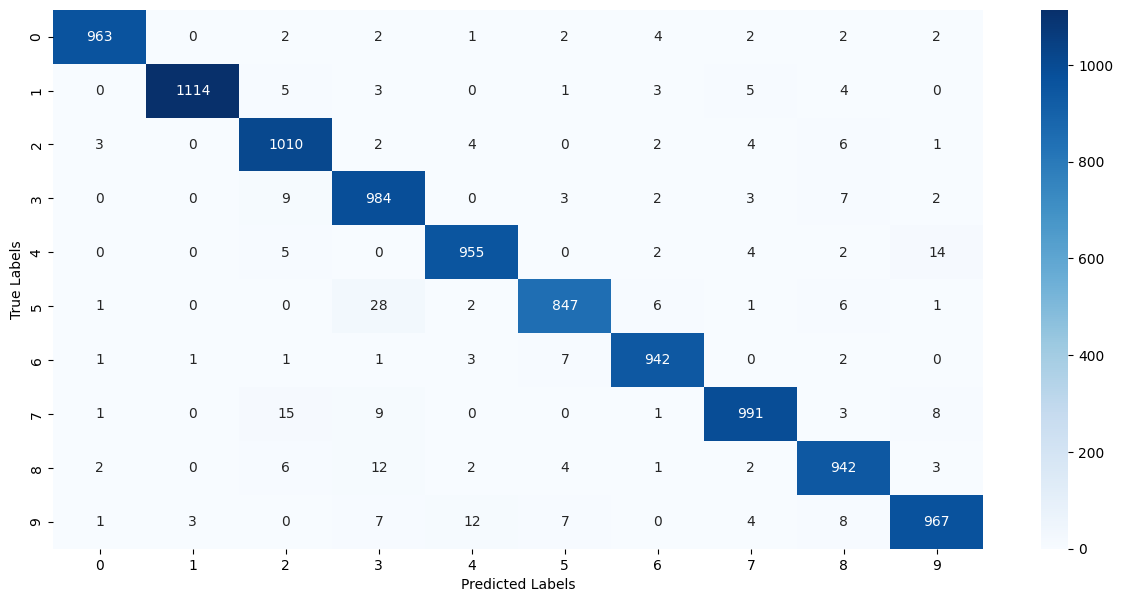

In [77]:
plt.figure(figsize=(15,7))
sns.heatmap(confu_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

# Building the Predictive System

In [78]:
input_image_path = 'image.png'

input_image = cv2.imread(input_image_path)

In [79]:
type(input_image)

numpy.ndarray

In [80]:
input_image.shape

(318, 318, 3)

The image is stored as a NumPy array (height × width × channels).

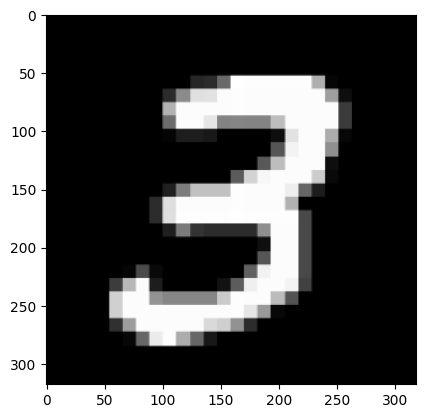

In [81]:
plt.imshow(input_image)
plt.show()

By default, cv2.imread() loads the image in BGR color format (not RGB!)

In [82]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

Converts the 3-channel image to grayscale (only one channel).

In [83]:
grayscale.shape

(318, 318)

In [84]:
input_image_resize = cv2.resize(grayscale, (28, 28))


Resizes the grayscale image to 28×28 pixels (like MNIST digit images)

In [85]:
input_image_resize.shape

(28, 28)

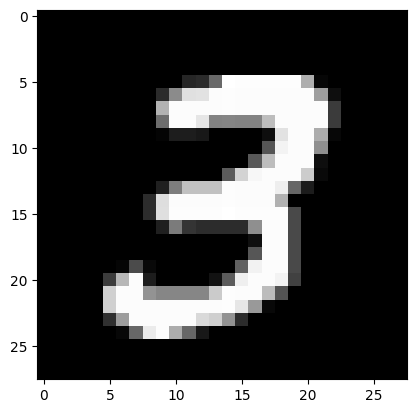

In [86]:
plt.imshow(input_image_resize, cmap='gray')
plt.show()

In [87]:
input_image_resize = input_image_resize/255

Normalizes pixel values from range [0, 255] → [0, 1]

In [88]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

Reshapes the image into shape [1, 28, 28].

1 → batch size (you’re predicting 1 image at a time).

28, 28 → the resized grayscale image.

This matches the input format your model expects

In [89]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[1.8012170e-08 9.5964856e-02 9.9937868e-01 1.0000000e+00 4.9231818e-17
  1.7399280e-01 5.5885918e-20 8.3364939e-05 1.4097238e-01 7.1732341e-03]]


In [90]:
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)

3


# Predictive System

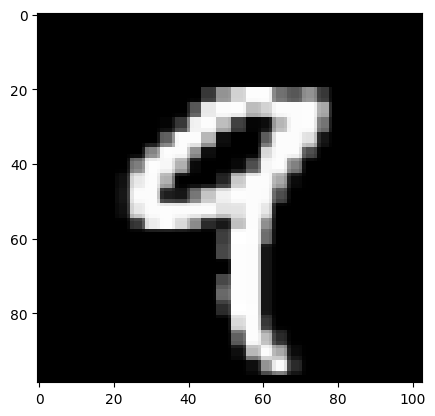

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
The Handwritten Recognised as : 9


In [91]:
input_image_path = input('Enter the image Path: ')
input_image = cv2.imread(input_image_path)
plt.imshow(input_image, cmap='gray')
plt.show()
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)
input_image_resize = cv2.resize(grayscale, (28,28))
input_image_resize = input_image_resize/255
image_reshaped = np.reshape(input_image_resize, [1, 28, 28])
input_prediction = model.predict(image_reshaped)
input_pred_label = np.argmax(input_prediction)
print("The Handwritten Recognised as :", input_pred_label)

Load image → convert to grayscale → resize to 28×28 → normalize → reshape → predict → print result.